In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
x = np.array([[1],[2],[3],[4]])
y = np.array([2,4,6,8])

In [ ]:
class RidgeRegression:
    """
        Ridge Regression class implements ridge regression using gradient descent.

        Attributes:
        X (array-like): Input features (1D or 2D).
        y (array-like): Target values.
        w (float or ndarray): Weight(s) for features.
        b (float): Bias term.
        alpha (float): Learning rate for gradient descent.
        num_iteration (int): Number of iterations for training.
        sse_value (list): Sum of squared errors for each iteration.
    """
    def __init__(self,x,y,lambda_):
        """ 
        Constructor to initialize input features and target.

            Parameters:
            x (array-like): Input feature(s), shape (n_samples,) or (n_samples, n_features).
            y (array-like): Target values, shape (n_samples,).
            
        """
        self.x=np.array(x)
        self.y=np.array(y)
        self.lambda_=lambda_


    def fit(self,alpha,num_iteration):
        """
        Trains the ridge regression model using gradient descent.

            Parameters:
            alpha (float): Learning rate for weight updates.
            num_iteration (int): Number of iterations for gradient descent.

            Updates:
            self.w: Trained weight(s).
            self.b: Trained bias.
            self.sse_value: Records SSE at each iteration for visualization.

        """
        self.w = 0
        self.b = 0
        self.alpha = alpha
        self.num_iteration= num_iteration
        n = len(self.x)
        self.sse_value= []
        for i in range(self.num_iteration):
            y_hat = self.w* self.x + self.b

            D_w = (2/n) * np.sum((y_hat-self.y)*self.x) + (2 *self.lambda_ / n) * self.w
            D_b = (2/n) * np.sum(y_hat-self.y) 
        

            self.w -=  self.alpha * D_w
            self.b -=  self.alpha * D_b
            
            sse = (np.sum((y_hat-self.y)**2))+(self.lambda_ *  (self.w ** 2))
            self.sse_value.append(sse)

    def predict(self,new_x):
            """
            Makes predictions using the trained model.

            Parameters:
            new_x (array-like): New input data for prediction.

            Returns:
            ndarray: Predicted values for the input data.
            """
            new_x=np.array(new_x)
            return self.w * new_x+ self.b
    
    def visualize(self):    
            """
            Visualizes training results.

            Plots:
            1. SSE (Sum of Squared Errors) over iterations.
            2. Regression line along with original data points.
            """
            plt.figure(figsize=(12,4))
            plt.subplot(1,2,1)
            plt.plot(range(self.num_iteration) , self.sse_value, label='sse')
            plt.xlabel("Iteration")
            plt.ylabel("SSE")
            plt.title("SSE over Iteration")
            plt.legend()
            plt.subplot(1,2,2)
            plt.scatter(self.x,self.y,color="blue",label="Data point")
            plt.plot(self.x,self.w*self.x+self.b,color="red" , label="Regression line")
            plt.xlabel("X")
            plt.ylabel("Y")
            plt.title("Ridge Regression fit line")
            plt.show()



    def calc_MSE(self):
        """
            Calculates Mean Squared Error (MSE) of the model on training data.

            Returns:
            float: Mean Squared Error.
            """
        y_hat = self.w * self.x + self.b
        mse = np.mean((self.y - y_hat) ** 2)
        return mse
    
    def calc_RMSE(self):
        """
            Calculates Root Mean Squared Error (RMSE) of the model on training data.

            Returns:
            float: Root Mean Squared Error.
            """
        return np.sqrt(self.calc_MSE())
    
    def calc_R2Score(self):
            """
            Calculates the R-squared (coefficient of determination) of the model.

            Returns:
            float: R² score, indicates how well the model explains variance in y.
            """
            y_hat = self.w * self.x + self.b
            sse = np.sum((self.y - y_hat) ** 2)
            sst = np.sum((self.y - np.mean(self.y)) ** 2)
            r2  = 1 - (sse / sst)
            return r2

In [4]:
l4=RidgeRegression(x,y,10)
l4.fit(0.0008,1000)

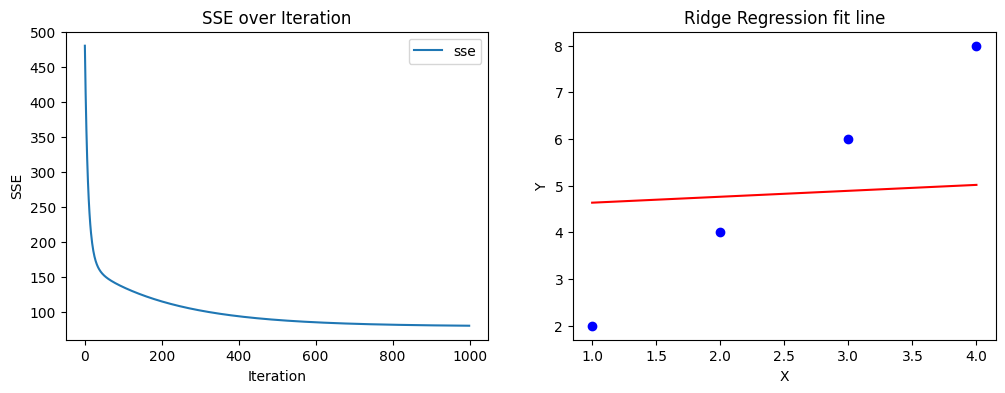

In [5]:
l4.visualize()

In [7]:
print(l4.predict(2))
print(l4.predict([3,4]))
print(l4.calc_MSE())
print(l4.calc_RMSE())
print(l4.calc_R2Score())

4.763643021503119
[4.8907764  5.01790978]
5.050060104396183
2.247233878437263
-3.040048083516946
